# `FreelyRotatingChain` demo

The `FreelyRotatingChain` class implements an ideal chain of N bonds of length `b` (default 3.8 A) with a fixed bond angle and free torsion. Its size is set by a single stiffness parameter, the characteristic ratio `c_inf` (default 2.0). `c_inf = 1` recovers the freely jointed chain; larger values give a stiffer, more extended ideal chain.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from afrc.polymer_models.frc import FreelyRotatingChain

seq = 'MASNDYTQQATQSYGAYPTQPGQGYSQQSSQPYGQQSYSGYSQSTDTSGYG'
model = FreelyRotatingChain(seq)

In [3]:
print(f"mean Re : {model.get_mean_end_to_end_distance():.2f} A")
print(f"RMS Re  : {model.get_root_mean_squared_end_to_end_distance():.2f} A")
print(f"mean Rg : {model.get_mean_radius_of_gyration():.2f} A")

mean Re : 35.10 A
RMS Re  : 38.09 A
mean Rg : 15.55 A


## Varying the characteristic ratio

Stiffer chains (larger `c_inf`) are more extended, while preserving ideal (nu = 0.5) scaling.

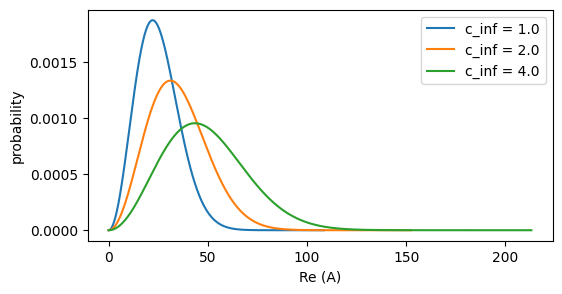

In [4]:
plt.figure(figsize=(6, 3))
for c in [1.0, 2.0, 4.0]:
    r, p = FreelyRotatingChain(seq, c_inf=c).get_end_to_end_distribution()
    plt.plot(r, p, label=f'c_inf = {c}')
plt.xlabel('Re (A)')
plt.ylabel('probability')
plt.legend()
plt.show()

## Recovering the freely jointed chain

At `c_inf = 1` the RMS end-to-end distance is exactly the ideal-chain value b*sqrt(N).

In [5]:
fjc_limit = FreelyRotatingChain(seq, c_inf=1.0)
print(f"RMS Re (c_inf=1) : {fjc_limit.get_root_mean_squared_end_to_end_distance():.3f} A")
print(f"b*sqrt(N)        : {3.8 * np.sqrt(len(seq)):.3f} A")

RMS Re (c_inf=1) : 27.137 A
b*sqrt(N)        : 27.137 A
